In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [3]:
clean = pd.read_csv(
    "../data/processed/occurrences_clean.csv"
)

print(clean.shape)

clean.head()

(34945, 10)


,accepted_name,early_interval,late_interval,collection_no,environment,formation,lat,lng,max_ma,min_ma
0,Marginalosia planata,Changhsingian,NaN,7204,NaN,Stephens,-41.299999,173.266663,254.14,251.902
1,Terrakea,Changhsingian,NaN,7204,NaN,Stephens,-41.299999,173.266663,254.14,251.902
2,Spiriferella,Changhsingian,NaN,7204,NaN,Stephens,-41.299999,173.266663,254.14,251.902
3,Martinia,Changhsingian,NaN,7204,NaN,Stephens,-41.299999,173.266663,254.14,251.902
4,Tomiopsis,Changhsingian,NaN,7204,NaN,Stephens,-41.299999,173.266663,254.14,251.902


In [4]:
interval_order = [
    "Changhsingian",
    "Griesbachian",
    "Dienerian",
    "Smithian",
    "Spathian",
    "Aegean",
    "Bithynian",
    "Pelsonian",
    "Illyrian",
    "Anisian"
]

In [5]:
occ_counts = (
    clean.groupby("early_interval")
    .size()
    .reindex(interval_order)
)

occ_counts

early_interval
Changhsingian    10046
Griesbachian      4122
Dienerian         1517
Smithian          4618
Spathian          3322
Aegean             557
Bithynian          950
Pelsonian         3314
Illyrian          2760
Anisian           3739
dtype: int64

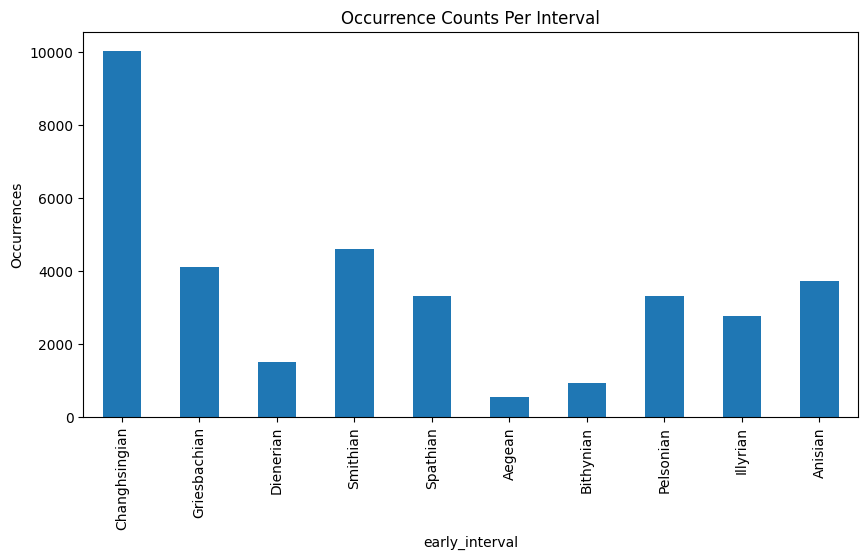

In [6]:
plt.figure(figsize=(10,5))

occ_counts.plot(kind="bar")

plt.title("Occurrence Counts Per Interval")
plt.ylabel("Occurrences")

plt.show()

In [7]:
raw_richness = (
    clean.groupby("early_interval")
    ["accepted_name"]
    .nunique()
    .reindex(interval_order)
)

raw_richness

early_interval
Changhsingian    1901
Griesbachian      441
Dienerian         306
Smithian          806
Spathian          736
Aegean            261
Bithynian         317
Pelsonian         538
Illyrian          596
Anisian          1223
Name: accepted_name, dtype: int64

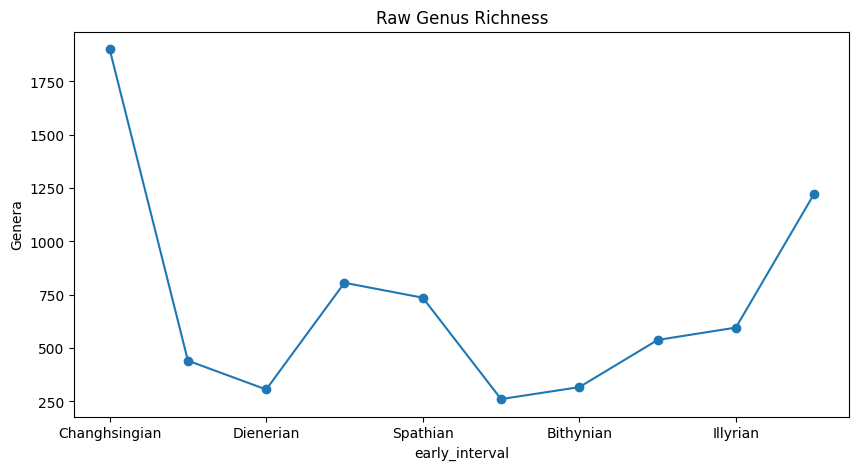

In [8]:
plt.figure(figsize=(10,5))

raw_richness.plot(
    marker="o"
)

plt.title("Raw Genus Richness")
plt.ylabel("Genera")

plt.show()

In [9]:
def rarefied_richness(
    taxa,
    sample_size,
    n_iter=1000
):

    taxa = np.array(taxa)

    richness_values = []

    for _ in range(n_iter):

        sample = np.random.choice(
            taxa,
            sample_size,
            replace=False
        )

        richness_values.append(
            len(set(sample))
        )

    return np.mean(richness_values)

In [10]:
sample_size = occ_counts.min()

sample_size

557

In [11]:
rarefied = {}

for interval in interval_order:

    taxa = clean.loc[
        clean["early_interval"] == interval,
        "accepted_name"
    ]

    rarefied[interval] = rarefied_richness(
        taxa,
        sample_size
    )

rarefied = pd.Series(rarefied)

rarefied

Changhsingian    379.382
Griesbachian     189.384
Dienerian        192.987
Smithian         289.144
Spathian         291.588
Aegean           261.000
Bithynian        225.409
Pelsonian        238.807
Illyrian         270.927
Anisian          380.240
dtype: float64

In [12]:
comparison = pd.DataFrame({
    "Raw": raw_richness,
    "Rarefied": rarefied
})

comparison

,Raw,Rarefied
Changhsingian,1901,379.382
Griesbachian,441,189.384
Dienerian,306,192.987
Smithian,806,289.144
Spathian,736,291.588
Aegean,261,261.000
Bithynian,317,225.409
Pelsonian,538,238.807
Illyrian,596,270.927
Anisian,1223,380.240


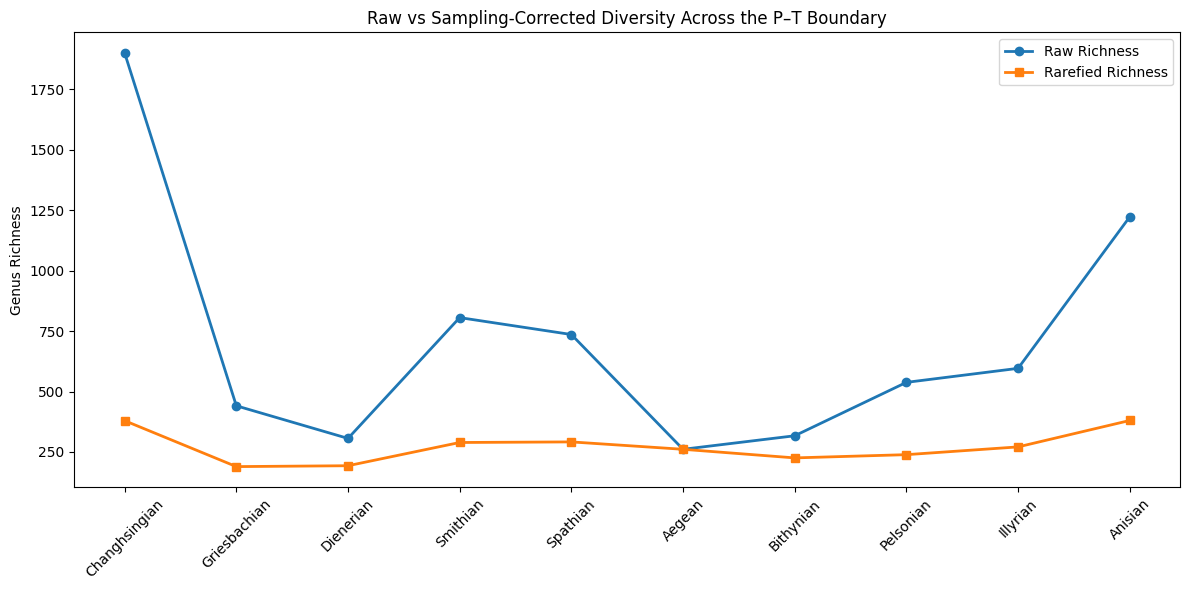

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison.index,
    comparison["Raw"],
    marker="o",
    linewidth=2,
    label="Raw Richness"
)

plt.plot(
    comparison.index,
    comparison["Rarefied"],
    marker="s",
    linewidth=2,
    label="Rarefied Richness"
)

plt.xticks(rotation=45)

plt.ylabel("Genus Richness")

plt.title(
    "Raw vs Sampling-Corrected Diversity Across the P–T Boundary"
)

plt.legend()

plt.tight_layout()

plt.show()

In [14]:
bias = (
    (comparison["Raw"] - comparison["Rarefied"])
    / comparison["Raw"]
) * 100

bias

Changhsingian    80.043030
Griesbachian     57.055782
Dienerian        36.932353
Smithian         64.126055
Spathian         60.382065
Aegean            0.000000
Bithynian        28.893060
Pelsonian        55.612082
Illyrian         54.542450
Anisian          68.909240
dtype: float64

In [15]:
bias.mean()

50.64961160068232

In [16]:
# Check if any interval has fewer occurrences than sample_size

check_df = pd.DataFrame({
    "Occurrences": occ_counts
})

check_df["Can_Rarefy"] = check_df["Occurrences"] >= sample_size

print(check_df)

                Occurrences  Can_Rarefy
early_interval                         
Changhsingian         10046        True
Griesbachian           4122        True
Dienerian              1517        True
Smithian               4618        True
Spathian               3322        True
Aegean                  557        True
Bithynian               950        True
Pelsonian              3314        True
Illyrian               2760        True
Anisian                3739        True


In [17]:
print(f"Rarefaction sample size = {sample_size}")

for interval in interval_order:
    taxa = clean.loc[
        clean["early_interval"] == interval,
        "accepted_name"
    ]

    print(
        f"{interval:<15} | "
        f"Occurrences = {len(taxa):<6} | "
        f"Rarefied to = {sample_size}"
    )

Rarefaction sample size = 557
Changhsingian   | Occurrences = 10046  | Rarefied to = 557
Griesbachian    | Occurrences = 4122   | Rarefied to = 557
Dienerian       | Occurrences = 1517   | Rarefied to = 557
Smithian        | Occurrences = 4618   | Rarefied to = 557
Spathian        | Occurrences = 3322   | Rarefied to = 557
Aegean          | Occurrences = 557    | Rarefied to = 557
Bithynian       | Occurrences = 950    | Rarefied to = 557
Pelsonian       | Occurrences = 3314   | Rarefied to = 557
Illyrian        | Occurrences = 2760   | Rarefied to = 557
Anisian         | Occurrences = 3739   | Rarefied to = 557


In [18]:
summary = pd.DataFrame({
    "Occurrences": occ_counts,
    "Raw_Richness": raw_richness,
    "Rarefied_Richness": rarefied
})

summary["Reduction_%"] = (
    (summary["Raw_Richness"] -
     summary["Rarefied_Richness"])
    / summary["Raw_Richness"]
) * 100

summary

,Occurrences,Raw_Richness,Rarefied_Richness,Reduction_%
Changhsingian,10046,1901,379.382,80.043030
Griesbachian,4122,441,189.384,57.055782
Dienerian,1517,306,192.987,36.932353
Smithian,4618,806,289.144,64.126055
Spathian,3322,736,291.588,60.382065
Aegean,557,261,261.000,0.000000
Bithynian,950,317,225.409,28.893060
Pelsonian,3314,538,238.807,55.612082
Illyrian,2760,596,270.927,54.542450
Anisian,3739,1223,380.240,68.909240


In [19]:
summary.to_csv(
    "../results/rarefaction_summary.csv"
)

print("Saved rarefaction summary")

Saved rarefaction summary


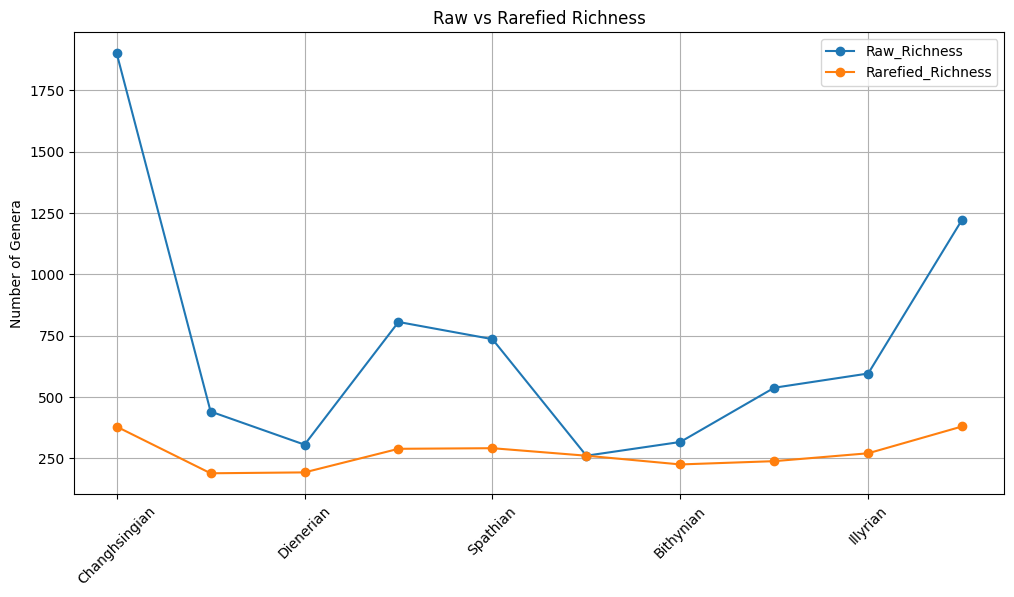

In [20]:
import matplotlib.pyplot as plt

summary[[
    "Raw_Richness",
    "Rarefied_Richness"
]].plot(
    figsize=(12,6),
    marker="o"
)

plt.title(
    "Raw vs Rarefied Richness"
)

plt.ylabel("Number of Genera")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [21]:
print(summary)

               Occurrences  Raw_Richness  Rarefied_Richness  Reduction_%
Changhsingian        10046          1901            379.382    80.043030
Griesbachian          4122           441            189.384    57.055782
Dienerian             1517           306            192.987    36.932353
Smithian              4618           806            289.144    64.126055
Spathian              3322           736            291.588    60.382065
Aegean                 557           261            261.000     0.000000
Bithynian              950           317            225.409    28.893060
Pelsonian             3314           538            238.807    55.612082
Illyrian              2760           596            270.927    54.542450
Anisian               3739          1223            380.240    68.909240


In [22]:
np.random.choice(taxa, sample_size, replace=False)

array(['Solemya funingensis', 'Sulcorhynchia anceps',
       'Pseudocorbula pseudogregaria', 'Avicula',
       'Neoschizodus laevigatus', 'Naticopsis (Vernelia) sublimneiformis',
       'Daonella', 'Protrachyceras longobardicum', 'Allocosmia turricula',
       'Punctospirella fragilis', 'Qilianoconcha circularis', 'Ptychites',
       'Decurtella', 'Schreyerites ragazzonii',
       'Nudirostralina griesbachi', 'Langsonella',
       'Aparimarhynchia dunrobinensis', 'Hungarites',
       'Leiophyllites marshalli', 'Trigonodus yunnanensis',
       'Mentzelia mentzeli', 'Arcestes cimmensis', 'Plagiostoma',
       'Entolium discites', 'Balatonites balatonicus', 'Hirsutella',
       'Megaphyllites sandalinus', 'Wairakirhynchia etaliana',
       'Myophoria harpa', 'Daonella sturi', 'Pecten',
       'Myophoria vulgaris', 'Posidonia', 'Arctogymnites sonini',
       'Daonella longobardica', 'Neoschizodus ovatus',
       'Cardinioides fidus', 'Mysidioptera', 'Paralepismatina semiconica',
       'Ma

In [23]:
presence.head()

NameError: name 'presence' is not defined

In [ ]:
import pandas as pd

clean = pd.read_csv(
    "../data/processed/occurrences_clean.csv"
)

print(clean.shape)

(34945, 10)


In [ ]:
interval_order = [
    "Changhsingian",
    "Griesbachian",
    "Dienerian",
    "Smithian",
    "Spathian",
    "Aegean",
    "Bithynian",
    "Pelsonian",
    "Illyrian",
    "Anisian"
]

In [ ]:
presence = pd.crosstab(
    clean["accepted_name"],
    clean["early_interval"]
)

presence = presence.reindex(
    columns=interval_order,
    fill_value=0
)

presence = (presence > 0).astype(int)

In [ ]:
print(presence.shape)

(5344, 10)


In [ ]:
presence.head()

early_interval,Changhsingian,Griesbachian,Dienerian,Smithian,Spathian,Aegean,Bithynian,Pelsonian,Illyrian,Anisian
accepted_name,,,,,,,,,,
Abichites,1,0,0,0,0,0,0,0,0,0
Abichites abichi,1,0,0,0,0,0,0,0,0,0
Abichites alibashiensis,1,0,0,0,0,0,0,0,0,0
Abichites ariaeii,1,0,0,0,0,0,0,0,0,0
Abichites infirmis,1,0,0,0,0,0,0,0,0,0


In [ ]:
survival_rows = []

for genus in presence.index:

    for i in range(len(interval_order) - 1):

        current_interval = interval_order[i]
        next_interval = interval_order[i + 1]

        if presence.loc[genus, current_interval] == 1:

            survival_rows.append({
                "genus": genus,
                "interval": current_interval,
                "survived": int(
                    presence.loc[genus, next_interval] == 1
                )
            })

survival_df = pd.DataFrame(survival_rows)

print(survival_df.shape)
survival_df.head()

(5902, 3)


,genus,interval,survived
0,Abichites,Changhsingian,0
1,Abichites abichi,Changhsingian,0
2,Abichites alibashiensis,Changhsingian,0
3,Abichites ariaeii,Changhsingian,0
4,Abichites infirmis,Changhsingian,0


In [ ]:
print(survival_df.shape)

(5902, 3)


In [ ]:
survival_df["survived"].value_counts()

0    4694
1    1208
Name: survived, dtype: int64

In [ ]:
print(presence.shape)

(5344, 10)


In [ ]:
clean["genus"] = (
    clean["accepted_name"]
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
)

In [ ]:
clean[["accepted_name", "genus"]].head(20)

,accepted_name,genus
0,Marginalosia planata,Marginalosia
1,Terrakea,Terrakea
2,Spiriferella,Spiriferella
3,Martinia,Martinia
4,Tomiopsis,Tomiopsis
5,Tomiopsis,Tomiopsis
6,Tomiopsis,Tomiopsis
7,Notospirifer,Notospirifer
8,Maorielasma,Maorielasma
9,Wairakiella rostrata,Wairakiella


In [ ]:
print("Unique accepted names:",
      clean["accepted_name"].nunique())

print("Unique genera:",
      clean["genus"].nunique())

Unique accepted names: 5344
Unique genera: 1644


In [ ]:
presence = pd.crosstab(
    clean["genus"],
    clean["early_interval"]
)

presence = presence.reindex(
    columns=interval_order,
    fill_value=0
)

presence = (presence > 0).astype(int)

print(presence.shape)

(1644, 10)


In [ ]:
survival_rows = []

for genus in presence.index:

    for i in range(len(interval_order)-1):

        current = interval_order[i]
        nxt = interval_order[i+1]

        if presence.loc[genus, current] == 1:

            survival_rows.append({
                "genus": genus,
                "interval": current,
                "survived": int(
                    presence.loc[genus, nxt] == 1
                )
            })

survival_df = pd.DataFrame(survival_rows)

print(survival_df.shape)

(2525, 3)


In [ ]:
survival_df["survived"].value_counts()

0    1536
1     989
Name: survived, dtype: int64

In [ ]:
lazarus_records = []

for genus in presence.index:

    row = presence.loc[genus].values

    for i in range(1, len(row)-1):

        if (
            row[i-1] == 1 and
            row[i] == 0 and
            row[i+1] == 1
        ):

            lazarus_records.append({
                "genus": genus,
                "missing_interval": interval_order[i]
            })

lazarus_df = pd.DataFrame(lazarus_records)

In [ ]:
print(lazarus_df.shape)

(196, 2)


In [ ]:
print(lazarus_df["genus"].nunique())

161


In [ ]:
lazarus_df.head()

,genus,missing_interval
0,Abrekia,Dienerian
1,Abrekia,Spathian
2,Acrochordiceras,Spathian
3,Adygella,Pelsonian
4,Allocosmia,Illyrian


In [ ]:
print(presence.shape)

(1644, 10)


In [ ]:
lazarus_records = []

for genus in presence.index:

    row = presence.loc[genus].values

    for i in range(1, len(row)-1):

        if (
            row[i-1] == 1 and
            row[i] == 0 and
            row[i+1] == 1
        ):
            lazarus_records.append({
                "genus": genus,
                "missing_interval": interval_order[i]
            })

lazarus_df = pd.DataFrame(lazarus_records)

print("Shape:", lazarus_df.shape)
print("Unique Lazarus genera:",
      lazarus_df["genus"].nunique())

lazarus_df.head()

Shape: (196, 2)
Unique Lazarus genera: 161


,genus,missing_interval
0,Abrekia,Dienerian
1,Abrekia,Spathian
2,Acrochordiceras,Spathian
3,Adygella,Pelsonian
4,Allocosmia,Illyrian


In [ ]:
genus_ranges = presence.sum(axis=1)

print(genus_ranges.describe())

count    1644.000000
mean        1.829075
std         1.529378
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
dtype: float64


In [24]:
presence.to_csv(
    "../data/processed/presence_matrix.csv"
)

lazarus_df.to_csv(
    "../data/processed/lazarus_taxa.csv",
    index=False
)

NameError: name 'presence' is not defined

In [25]:
import pandas as pd

for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame) and not name.startswith("_"):
        print(name, "->", val.shape)

clean -> (34945, 10)
comparison -> (10, 2)
check_df -> (10, 2)
summary -> (10, 4)


In [26]:
print("comparison:")
print(comparison.head())
print()
print("check_df:")
print(check_df.head())
print()
print("summary:")
print(summary.head())

comparison:
                Raw  Rarefied
Changhsingian  1901   379.382
Griesbachian    441   189.384
Dienerian       306   192.987
Smithian        806   289.144
Spathian        736   291.588

check_df:
                Occurrences  Can_Rarefy
early_interval                         
Changhsingian         10046        True
Griesbachian           4122        True
Dienerian              1517        True
Smithian               4618        True
Spathian               3322        True

summary:
               Occurrences  Raw_Richness  Rarefied_Richness  Reduction_%
Changhsingian        10046          1901            379.382    80.043030
Griesbachian          4122           441            189.384    57.055782
Dienerian             1517           306            192.987    36.932353
Smithian              4618           806            289.144    64.126055
Spathian              3322           736            291.588    60.382065


In [27]:
diversity_export = summary.reset_index().rename(columns={
    "early_interval": "interval",
    "Occurrences": "n_collections",
    "Raw_Richness": "raw_richness",
    "Rarefied_Richness": "corrected_richness"
})

print(diversity_export.columns.tolist())
print(diversity_export.head())

import os
os.makedirs("../results/processed", exist_ok=True)
diversity_export.to_csv("../results/processed/diversity_raw_vs_corrected.csv", index=False)
print("Saved diversity CSV")

['index', 'n_collections', 'raw_richness', 'corrected_richness', 'Reduction_%']
           index  n_collections  raw_richness  corrected_richness  Reduction_%
0  Changhsingian          10046          1901             379.382    80.043030
1   Griesbachian           4122           441             189.384    57.055782
2      Dienerian           1517           306             192.987    36.932353
3       Smithian           4618           806             289.144    64.126055
4       Spathian           3322           736             291.588    60.382065
Saved diversity CSV


In [ ]:
lazarus_df["genus"].nunique()

161

In [ ]:
lazarus_df["genus"].nunique()

161